In [ ]:
!pip install -q kaggle
!mkdir ~/.kaggle

In [ ]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [ ]:
# Once logged in, try the download again
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yidazhang07/bridge-cracks-image")

print("Path to dataset files:", path)
#path = kagglehub.dataset_download("yidazhang07/DeepPCB")


#print("Path to dataset files:", path)

100%|██████████| 151M/151M [00:01<00:00, 94.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yidazhang07/bridge-cracks-image/versions/1


In [ ]:
ls /root/.cache/kagglehub/datasets/yidazhang07/bridge-cracks-image/versions/1

Bridge_Crack_Image/  CrackForest/  DeepPCB/  Magnetic-Tile-Defect/


In [ ]:
from PIL import Image
#img_example=Image.open("/root/.cache/kagglehub/datasets/yidazhang07/bridge-cracks-image/versions/1/Bridge_Crack_Image/DBCC_Training_Data_Set/train/crack1433.jpeg")

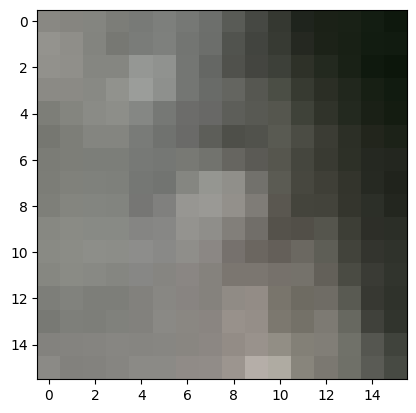

In [ ]:
import matplotlib.pyplot as plt
#plt.imshow(img_example)
#img_example

In [ ]:
## image and label class
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import tv_tensors
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

class PCBDefectDataset(Dataset):
    def __init__(self, manifest_lines, data_dir='', transforms=None):
        self.data_dir = data_dir
        self.transforms = transforms
        self.samples = []

        # Process the lines passed directly
        for line in manifest_lines:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) == 2:
                img_path, ann_path = parts
                # Keeping your specific string replacement logic
                self.samples.append((img_path.replace('.jpg',"_test.jpg"), ann_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_rel_path, ann_rel_path = self.samples[idx]

        img_path = os.path.join(self.data_dir, img_rel_path)
        ann_path = os.path.join(self.data_dir, ann_rel_path)

        # Load image with PIL
        image = Image.open(img_path).convert("RGB")
        #image=tv_tensors.Image(image)
        w, h = image.size  # PIL gets size as (width, height)

        boxes = []
        labels = []

        # Parse the annotation file
        if os.path.exists(ann_path):
            with open(ann_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue

                    parts = line.split()
                    if len(parts) >= 5:
                        x1, y1, x2, y2 = map(float, parts[:4])
                        class_id = int(parts[4])

                        # Safety check: ensure xmin < xmax and ymin < ymax
                        x_min, x_max = min(x1, x2), max(x1, x2)
                        y_min, y_max = min(y1, y2), max(y1, y2)

                        boxes.append([x_min, y_min, x_max, y_max])
                        labels.append(class_id)

        # Convert annotations to pure PyTorch tensors
        if len(boxes) > 0:
            boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
            labels_tensor = torch.tensor(labels, dtype=torch.int64)
        else:
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.int64)

        # Construct the target dict using tv_tensors.BoundingBoxes
        target = {}
        # This wrapper tells v2 transforms that these coordinates are bounding boxes
        target["boxes"] = tv_tensors.BoundingBoxes(
            boxes_tensor,
            format=tv_tensors.BoundingBoxFormat.XYXY,
            canvas_size=(h, w)
        )
        target["labels"] = labels_tensor

        # Apply torchvision v2 transforms
        # The v2 API automatically detects the BoundingBoxes object in the dict
        # and applies spatial transformations (flips, rotations) to it along with the image.
        if self.transforms is not None:
            image, target = self.transforms(image, target)
            #print('XXX')
        return image, target

In [ ]:
def get_v2_transforms(train=True):
    """
    Returns a torchvision.transforms.v2 pipeline.
    """
    if train:
        return v2.Compose([
            # Convert PIL image into a tv_tensors.Image
            v2.ToImage(),

            # Spatial augmentations: automatically applied to both image and bounding boxes
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomVerticalFlip(p=0.5),
            v2.RandomRotation(degrees=15),

            # Convert image to float32 and normalize pixels to [0, 1] range
            # (Replaces the old ToTensor() behavior)
            v2.ToDtype(torch.float32, scale=True),

            # Optional: Add mean/std normalization if using pre-trained weights like ResNet
            # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            # --- THE FIX ---
            # This will automatically remove any bounding boxes that have
            # been degenerated (zero area) by the rotation or flipping.
            v2.SanitizeBoundingBoxes(),
        ])
    else:
        # Validation/Test pipeline
        return v2.Compose([
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

In [ ]:
data_dir = '/root/.cache/kagglehub/datasets/yidazhang07/bridge-cracks-image/versions/1/DeepPCB/PCBData/'

# Read trainval.txt
with open(os.path.join(data_dir, 'trainval.txt'), 'r') as f:
    trainval_lines = f.readlines()

# Read test.txt
with open(os.path.join(data_dir, 'test.txt'), 'r') as f:
    test_lines = f.readlines()

# Split trainval into 80% train, 20% validation
train_lines, val_lines = train_test_split(trainval_lines, test_size=0.2, random_state=42)

# Create Datasets
train_dataset = PCBDefectDataset(train_lines, data_dir=data_dir, transforms=get_v2_transforms(train=True))
val_dataset = PCBDefectDataset(val_lines, data_dir=data_dir, transforms=get_v2_transforms(train=False))
test_dataset = PCBDefectDataset(test_lines, data_dir=data_dir, transforms=get_v2_transforms(train=False))

# Create DataLoaders
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)


# Test the loader
for images, targets in train_loader:
    print(f"Batch contains {len(images)} images.")
    print(images[0][0].cpu().numpy())
    #print(images[0])
    print(f"First image boxes shape: {targets[0]['boxes'].shape}")
    print(f"First image labels: {targets[0]['labels']}")
    break

Batch contains 4 images.
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
First image boxes shape: torch.Size([7, 4])
First image labels: tensor([1, 2, 3, 5, 6, 1, 5])


In [ ]:
# from torch.utils.data import DataLoader
# from torchvision.transforms import ToTensor

# # Example usage mapping to your data directory
# dataset = PCBDefectDataset(

#     transforms=None # You can add torchvision transforms here
# )

# # DataLoader setup (Use collate_fn to handle variable numbers of bounding boxes per image)
# def collate_fn(batch):
#     return tuple(zip(*batch))

# dataloader = DataLoader(
#     dataset,
#     batch_size=4,
#     shuffle=True,
#     collate_fn=collate_fn
# )



In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_augmented_sample(image_tensor, target):
    """
    Plots the image tensor and draws the bounding boxes on top.

    Args:
        image_tensor (torch.Tensor): Image tensor of shape (C, H, W) in [0, 1] range.
        target (dict): Dictionary containing 'boxes' and 'labels'.
    """
    # 1. Convert the image tensor (C, H, W) back to a numpy array (H, W, C)
    # The image is scaled to [0, 1] by v2.ToDtype(), which matplotlib handles perfectly.
    img_np = image_tensor.permute(1, 2, 0).cpu().numpy()

    # Define your specific PCB defect classes
    class_map = {
        1: 'open',
        2: 'short',
        3: 'mousebite',
        4: 'spur',
        5: 'copper',
        6: 'pin-hole'
    }

    # 2. Setup the plot
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img_np)

    # 3. Extract boxes and labels
    boxes = target['boxes'].cpu().numpy()
    labels = target['labels'].cpu().numpy()

    # 4. Draw each bounding box and its label
    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        width = xmax - xmin
        height = ymax - ymin

        # Create a Rectangle patch
        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)

        # Add the class text slightly above the box
        class_name = class_map.get(label, f"ID: {label}")
        ax.text(
            xmin, ymin - 5, class_name,
            color='black', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='lime', alpha=0.7, edgecolor='none', pad=2)
        )

    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Grab one batch of data
data_iter = iter(train_loader)
images, targets = next(data_iter)

# Let's plot the first two images in the batch to verify
print("Plotting Image 0...")
if 0:
  plot_augmented_sample(images[0], targets[0])

  if len(images) > 1:
      print("Plotting Image 1...")
      plot_augmented_sample(images[1], targets[1])

Plotting Image 0...


In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

class CustomCNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        # Standard CNN architecture for feature extraction
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Halves spatial dimensions

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Final feature layer
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
        )

        # Faster R-CNN strictly requires an 'out_channels' attribute on the backbone
        self.out_channels = 256

    def forward(self, x):
        return self.features(x)


## model
def create_defect_detector(num_classes):
    """
    Combines the custom backbone with PyTorch's Faster R-CNN detection head.
    """
    backbone = CustomCNNBackbone()

    # Define anchor sizes and aspect ratios for the Region Proposal Network (RPN)
    # These sizes represent the scale of defects on your PCBs
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128, 256),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )

    # Feature map pooling setup
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'], # Custom backbones typically output to '0'
        output_size=7,
        sampling_ratio=2
    )

    # Assemble the model
    model = FasterRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )

    return model

In [ ]:
import torchvision.ops as ops

def evaluate_predictions(predictions, targets, iou_threshold=0.5, score_threshold=0.5):
    """
    Computes True Positives (TP), False Positives (FP), False Negatives (FN),
    and average IoU for a batch.
    """
    tp = fp = fn = 0
    total_iou = 0.0
    matched_boxes = 0

    for pred, target in zip(predictions, targets):
        pred_boxes = pred['boxes']
        pred_labels = pred['labels']
        pred_scores = pred['scores']

        # Filter predictions by confidence score
        keep = pred_scores >= score_threshold
        pred_boxes = pred_boxes[keep]
        pred_labels = pred_labels[keep]

        gt_boxes = target['boxes']
        gt_labels = target['labels']

        if len(gt_boxes) == 0:
            fp += len(pred_boxes)
            continue
        if len(pred_boxes) == 0:
            fn += len(gt_boxes)
            continue

        # Calculate IoU matrix between all preds and all ground truths
        iou_matrix = ops.box_iou(pred_boxes, gt_boxes)

        # Track which GT boxes have been matched to avoid double counting
        gt_matched = torch.zeros(len(gt_boxes), dtype=torch.bool)

        for p_idx in range(len(pred_boxes)):
            # Find the best ground truth match for this prediction
            match_iou, gt_idx = iou_matrix[p_idx].max(dim=0)

            if match_iou >= iou_threshold and not gt_matched[gt_idx] and pred_labels[p_idx] == gt_labels[gt_idx]:
                tp += 1
                gt_matched[gt_idx] = True
                total_iou += match_iou.item()
                matched_boxes += 1
            else:
                fp += 1

        # Any ground truth not matched is a false negative
        fn += (~gt_matched).sum().item()

    avg_iou = (total_iou / matched_boxes) if matched_boxes > 0 else 0.0
    return tp, fp, fn, avg_iou

In [ ]:
# Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Number of classes: 6 defect classes + 1 background class = 7
num_classes = 7
model = create_defect_detector(num_classes).to(device)

# Optimizer: AdamW (Adam with decoupled weight decay)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Learning Rate Scheduler: Gradually decreases the LR for smoother convergence
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

Using device: cuda


In [ ]:
import math
import sys

num_epochs = 20
best_f1 = 0.0

for epoch in range(num_epochs):
    # ==========================
    #        TRAINING
    # ==========================
    model.train()
    epoch_cls_loss = 0
    epoch_box_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        # Faster R-CNN provides separate losses for classification and box regression
        cls_loss = loss_dict['loss_classifier']
        box_loss = loss_dict['loss_box_reg']
        losses = sum(loss for loss in loss_dict.values())

        if not math.isfinite(losses.item()):
            print(f"\nLoss is {losses.item()}, stopping training")
            sys.exit(1)

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        epoch_cls_loss += cls_loss.item()
        epoch_box_loss += box_loss.item()

    lr_scheduler.step()

    avg_cls_loss = epoch_cls_loss / len(train_loader)
    avg_box_loss = epoch_box_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Train | Cls Loss: {avg_cls_loss:.4f} | Box Loss: {avg_box_loss:.4f}")

    # ==========================
    #       VALIDATION
    # ==========================
    model.eval()
    total_tp = total_fp = total_fn = 0
    epoch_ious = []

    with torch.no_grad():
        for images, targets in val_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # In eval mode, the model returns predictions instead of losses
            predictions = model(images)

            tp, fp, fn, avg_iou = evaluate_predictions(predictions, targets, iou_threshold=0.5, score_threshold=0.5)
            total_tp += tp
            total_fp += fp
            total_fn += fn
            if avg_iou > 0:
                epoch_ious.append(avg_iou)

    # Calculate metrics
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    mean_val_iou = sum(epoch_ious) / len(epoch_ious) if epoch_ious else 0

    print(f"Epoch [{epoch+1}/{num_epochs}] Val   | F1: {f1_score:.4f} | mIoU: {mean_val_iou:.4f} | P: {precision:.4f} | R: {recall:.4f}")

    # ==========================
    #    SAVE BEST MODEL
    # ==========================
    if f1_score > best_f1:
        best_f1 = f1_score
        print(f"--> New best model found! Saving 'best_model.pth' with F1: {best_f1:.4f}")
        torch.save(model.state_dict(), 'best_model.pth')

print("Training Complete!")

# To load the best model later for test set:
# model.load_state_dict(torch.load('best_model.pth'))

Epoch [1/20] Train | Cls Loss: 0.3257 | Box Loss: 0.2735
Epoch [1/20] Val   | F1: 0.5038 | mIoU: 0.7754 | P: 0.6029 | R: 0.4327
--> New best model found! Saving 'best_model.pth' with F1: 0.5038
Epoch [2/20] Train | Cls Loss: 0.2301 | Box Loss: 0.2733
Epoch [2/20] Val   | F1: 0.7379 | mIoU: 0.7489 | P: 0.7130 | R: 0.7647
--> New best model found! Saving 'best_model.pth' with F1: 0.7379
Epoch [3/20] Train | Cls Loss: 0.1747 | Box Loss: 0.2475
Epoch [3/20] Val   | F1: 0.7785 | mIoU: 0.7642 | P: 0.7024 | R: 0.8730
--> New best model found! Saving 'best_model.pth' with F1: 0.7785
Epoch [4/20] Train | Cls Loss: 0.1437 | Box Loss: 0.2246
Epoch [4/20] Val   | F1: 0.8500 | mIoU: 0.7506 | P: 0.8104 | R: 0.8937
--> New best model found! Saving 'best_model.pth' with F1: 0.8500
Epoch [5/20] Train | Cls Loss: 0.1262 | Box Loss: 0.2118
Epoch [5/20] Val   | F1: 0.8469 | mIoU: 0.7715 | P: 0.7831 | R: 0.9220
Epoch [6/20] Train | Cls Loss: 0.1169 | Box Loss: 0.2048
Epoch [6/20] Val   | F1: 0.8707 | mIoU:

In [ ]:
%cd /content

/content
